<h2 style="color:white; background-color:green; padding:5px; border-radius:5px;">
<strong>VyapaarSetu  Analysis</strong>
</h2>

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Export Data 

In [105]:
df = pd.read_csv("vyapaarsetu_transactions.csv")

In [106]:
df.head()

,transaction_id,customer_id,customer_name,age,gender,city,product_category,product_id,product_name,quantity,...,delivery_days,order_status,return_delivery_charge,order_source,sales_channel,rating,complaint_raised,month,month_name,year
0,TXN-05097,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
1,TXN-13031,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
2,TXN-19316,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
3,TXN-09013,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,4,Delivered,0,Website,Website,3.3,No,1,January,2023
4,TXN-18037,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,4,Delivered,0,Website,Website,3.3,No,1,January,2023


<h2 style="color:Green;"><b>Data Cleaning<b></h2>

In [107]:
# Shape of the dataframe 
shape = df.shape
print(shape)

(21345, 27)


In [108]:
# Data Type
df.dtypes

transaction_id             object
customer_id                object
customer_name              object
age                         int64
gender                     object
city                       object
product_category           object
product_id                 object
product_name               object
quantity                    int64
unit_price                float64
total_price               float64
discount_percent            int64
final_amount              float64
delivery_charge             int64
payment_method             object
order_date                 object
delivery_days               int64
order_status               object
return_delivery_charge      int64
order_source               object
sales_channel              object
rating                    float64
complaint_raised           object
month                       int64
month_name                 object
year                        int64
dtype: object

In [109]:
# Column name 
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year'],
      dtype='object')

<h2 style="color:Green;"><b>Null Values<b></h2>

In [110]:
# Find null values 

null_value = df.isnull().sum()
print(null_value)

transaction_id               0
customer_id                  0
customer_name                0
age                          0
gender                       0
city                         0
product_category             0
product_id                   0
product_name                 0
quantity                     0
unit_price                   0
total_price                  0
discount_percent             0
final_amount                 0
delivery_charge              0
payment_method               0
order_date                   0
delivery_days                0
order_status                 0
return_delivery_charge       0
order_source                 0
sales_channel                0
rating                    2038
complaint_raised             0
month                        0
month_name                   0
year                         0
dtype: int64


## Handle Null Value 

In [111]:
# Replace null value with Unknown Custoemrs in customer Name table 


df = df.sort_values(['customer_id', 'order_date'])

df['customer_name'] = df.groupby('customer_id')['customer_name']\
                        .transform(lambda x: x.ffill().bfill())

df['customer_name'] = df['customer_name'].fillna('Unknown Customer')

In [112]:

# 2. Step 1: Fill missing names using the Customer ID "Lookup"
# We create a dictionary where each ID is linked to a name found in the data
name_lookup = df.dropna(subset=['customer_name']).drop_duplicates('customer_id').set_index('customer_id')['customer_name']

# If a name is NaN, we look up the customer_id in our 'name_lookup' and fill it
df['customer_name'] = df['customer_name'].fillna(df['customer_id'].map(name_lookup))

# 3. Step 2: Handle "Unknown Customer" for one-time buyers
# Count how many times each customer_id appears in the whole dataset
order_frequencies = df['customer_id'].value_counts()

# We check two conditions: 
# (The name is still empty) AND (The customer has exactly 1 order)
is_still_null = df['customer_name'].isna()
is_single_order = df['customer_id'].map(order_frequencies) == 1

df.loc[is_still_null & is_single_order, 'customer_name'] = 'Unknown Customer'

# 4. Step 3: Permanent Change
# This overwrites the CSV file with the cleaned data
df.to_csv('vyapaarsetu_transactions.csv', index=False)

print("Data cleaning complete. File updated permanently.")

Data cleaning complete. File updated permanently.


In [113]:
df.head()

,transaction_id,customer_id,customer_name,age,gender,city,product_category,product_id,product_name,quantity,...,delivery_days,order_status,return_delivery_charge,order_source,sales_channel,rating,complaint_raised,month,month_name,year
0,TXN-05097,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
1,TXN-13031,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
2,TXN-19316,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
3,TXN-09013,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,4,Delivered,0,Website,Website,3.3,No,1,January,2023
4,TXN-18037,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,4,Delivered,0,Website,Website,3.3,No,1,January,2023


In [114]:
df.isnull().sum()

transaction_id               0
customer_id                  0
customer_name                0
age                          0
gender                       0
city                         0
product_category             0
product_id                   0
product_name                 0
quantity                     0
unit_price                   0
total_price                  0
discount_percent             0
final_amount                 0
delivery_charge              0
payment_method               0
order_date                   0
delivery_days                0
order_status                 0
return_delivery_charge       0
order_source                 0
sales_channel                0
rating                    2038
complaint_raised             0
month                        0
month_name                   0
year                         0
dtype: int64

In [115]:
# Build a product_id → product_name mapping
# from rows where product_name is NOT null
product_map = df.dropna(subset=['product_name']) \
                .drop_duplicates('product_id') \
                .set_index('product_id')['product_name'] \
                .to_dict()

# Fill null product_name using product_id as key
df['product_name'] = df.apply(
    lambda row: product_map.get(row['product_id'], row['product_name'])
    if pd.isnull(row['product_name']) else row['product_name'],
    axis=1
)

print(f"Nulls remaining : {df['product_name'].isnull().sum()}")

Nulls remaining : 0


In [116]:
# Fill payment_method using city-wise mode
df['payment_method'] = df.groupby('city')['payment_method'] \
                         .transform(lambda x: x.fillna(x.mode()[0]))

# If still null (city was also null) → fill with global mode
global_mode = df['payment_method'].mode()[0]
df['payment_method'] = df['payment_method'].fillna(global_mode)

print(f"Nulls remaining : {df['payment_method'].isnull().sum()}")

Nulls remaining : 0


In [117]:
df.describe()

,age,quantity,unit_price,total_price,discount_percent,final_amount,delivery_charge,delivery_days,return_delivery_charge,rating,month,year
count,21345.000000,21345.000000,21345.000000,21345.000000,21345.000000,21345.000000,21345.000000,21345.000000,21345.000000,19307.000000,21345.000000,21345.0
mean,41.316374,1.993816,1108.639767,2241.925964,11.036777,1994.698476,19.019208,3.742750,10.681377,3.622826,6.552588,2023.0
std,13.381085,1.189684,771.925498,2224.211052,9.183562,1996.888793,23.879649,1.715887,27.014277,0.944849,3.443654,0.0
min,18.000000,-5.000000,0.000000,149.750000,0.000000,93.490000,0.000000,1.000000,0.000000,1.000000,1.000000,2023.0
25%,30.000000,1.000000,531.730000,828.570000,5.000000,723.370000,0.000000,2.000000,0.000000,3.100000,4.000000,2023.0
50%,41.000000,2.000000,934.430000,1466.980000,10.000000,1302.400000,0.000000,4.000000,0.000000,3.800000,7.000000,2023.0
75%,53.000000,3.000000,1373.550000,2830.830000,15.000000,2530.950000,49.000000,5.000000,0.000000,4.300000,10.000000,2023.0
max,65.000000,5.000000,3994.660000,17764.200000,40.000000,17153.700000,49.000000,8.000000,79.000000,8.000000,12.000000,2023.0


## Change order date Object to date format 

In [118]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

C:\Users\pushp\AppData\Local\Temp\ipykernel_12176\1484887558.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)


In [119]:
df.dtypes

transaction_id                    object
customer_id                       object
customer_name                     object
age                                int64
gender                            object
city                              object
product_category                  object
product_id                        object
product_name                      object
quantity                           int64
unit_price                       float64
total_price                      float64
discount_percent                   int64
final_amount                     float64
delivery_charge                    int64
payment_method                    object
order_date                datetime64[ns]
delivery_days                      int64
order_status                      object
return_delivery_charge             int64
order_source                      object
sales_channel                     object
rating                           float64
complaint_raised                  object
month           

### 1. Revenue Overview: What is the total revenue (sum of final_amount) generated by the platform?

In [120]:
tr = df['final_amount'].sum()
total_revenue = round(tr/10000000 ,2) 
print(f"Total revenue is:- {total_revenue}Cr")
 

Total revenue is:- 4.26Cr


### 2. Top City: Which city contributes the highest number of transactions?

In [121]:
revenue_by_city = df.groupby("city")["final_amount"].sum().sort_values(ascending= False)
print(revenue_by_city)

city
Indore      15519340.79
Bhopal      11632789.40
Jabalpur     6558053.38
Gwalior      5698981.21
Ujjain       3167674.18
Name: final_amount, dtype: float64


### 3. Popular Categories: What are the top 3 product_category based on the total quantity sold?

In [122]:
popular_category = df.groupby("product_category")["quantity"].sum().sort_values(ascending= False).head(3)
print(popular_category)

product_category
Fashion        12634
Electronics    12223
Beauty          9860
Name: quantity, dtype: int64


### 4. Demographics: What is the average age and the most common gender of the shoppers in this dataset?

In [123]:
avg_age = round(df["age"].mean(),2)
print(f"Avg age in this dataset is:-{avg_age}")

Avg age in this dataset is:-41.32


In [124]:
# Most common gender in this dataset 

gender_df = df.groupby("gender")["gender"].count().sort_values(ascending= False).head(1)
# print(gender_df)

print(f"Most common gender is {gender_df} and avg age is {avg_age}")

Most common gender is gender
Female    11553
Name: gender, dtype: int64 and avg age is 41.32


### 5. Payment Trends: Which payment_method is used most frequently by customers?

In [125]:
payment_trends = df.groupby("payment_method")["payment_method"].count().sort_values(ascending= False)
payment_trends

payment_method
UPI            6981
COD            5195
Debit Card     3695
Credit Card    3072
Wallet         2402
Name: payment_method, dtype: int64

### 1. Monthly Sales Trend: Convert order_date to a datetime object and identify which month saw the highest total sales volume.

In [126]:
# Create month No column 
df["month"] = df["order_date"].dt.month

In [127]:
# Create month name columns
df["month_name"] = df["order_date"].dt.month_name()

In [128]:
# Create year columns 

df["year"] = df["order_date"].dt.year

In [129]:
monthly_revenue = df.groupby("month_name")["final_amount"].sum().sort_values(ascending= False)
monthly_revenue_lk = round(monthly_revenue / 1e5,2)

print(monthly_revenue_lk)

month_name
December     37.67
August       37.38
April        37.27
January      36.63
July         36.42
May          36.36
November     35.80
February     35.45
March        35.39
October      32.93
September    32.48
June         31.98
Name: final_amount, dtype: float64


### 2. Gender-Based Spending: Is there a significant difference in the average final_amount spent between Male and Female customers?

In [130]:
gender_revenue = df.groupby("gender")["final_amount"].sum()
gender_revenue_cr = round(gender_revenue / 1e7,2)

gender_revenue_cr

gender
Female    2.08
Male      2.18
Name: final_amount, dtype: float64

### 3. Order Success Rate: What percentage of total orders have an order_status of 'Delivered' vs. 'Cancelled' or 'Returned'?

In [131]:
os = df.groupby("order_status")["order_status"].count().sort_values(ascending= False)

oss = round((os / df["order_status"].count()) * 100.0,2)
print(oss)

order_status
Delivered    78.58
Returned     13.19
Cancelled     8.23
Name: order_status, dtype: float64


### 4. Product Satisfaction: Which product_category has the highest average rating? Are there categories with a high number of complaint_raised?

In [132]:
# Highest Avg Rating 
product_satisfaction = round(df.groupby("product_category")["rating"].mean(),2).sort_values(ascending= False)
product_satisfaction

product_category
Electronics    3.68
Sports         3.67
Beauty         3.61
Fashion        3.55
Name: rating, dtype: float64

In [133]:
product_complaint = df.groupby("product_category")["complaint_raised"].count().sort_values(ascending= False)
product_complaint

product_category
Fashion        6287
Electronics    6130
Beauty         4990
Sports         3938
Name: complaint_raised, dtype: int64

### 5. Discount Effectiveness: Do transactions with a discount_percent greater than 10% result in a higher average quantity compared to those with no discount?

In [134]:
df.head()

,transaction_id,customer_id,customer_name,age,gender,city,product_category,product_id,product_name,quantity,...,delivery_days,order_status,return_delivery_charge,order_source,sales_channel,rating,complaint_raised,month,month_name,year
0,TXN-05097,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
1,TXN-13031,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
2,TXN-19316,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,1,Delivered,0,App,App,4.8,No,1,January,2023
3,TXN-09013,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,4,Delivered,0,Website,Website,3.3,No,1,January,2023
4,TXN-18037,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,4,Delivered,0,Website,Website,3.3,No,1,January,2023


In [135]:
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year'],
      dtype='object')

In [136]:
# Avg quantity compared with zero quantity
# 1. 10 % and more then 10 % discount 
avg_qty_10discount = round(df[df["discount_percent"]  > 10]["quantity"].mean(),2)
print(avg_qty_10discount)

1.99


In [137]:
# Product with zero % discount with quantity 

avg_quantity_with0 = round(df[df["discount_percent"] == 0]["quantity"].mean(),2)
print(avg_quantity_with0)

1.98


In [138]:
# Find the difference between product with 10 % and more discount and 0 discount 
diff_discount = round(avg_qty_10discount - avg_quantity_with0,2)
print(diff_discount)


# 10 % and more is slidelly better then normal and 0 discount. 

0.01


### 6. Discount Effectiveness: Do transactions with a discount_percent greater than 10% result in a higher average revenue compared to those with no discount?

In [139]:
# Difference between 10% and more discount product and zero discount product 

avg_10_discount = round(df.loc[df["discount_percent"] > 10, "final_amount"].mean(),2)

# avg_parchase amount if dicount is 10% and more 
print(f"avg_parchase amount if dicount is 10% and more is:- {avg_10_discount}")

avg_parchase amount if dicount is 10% and more is:- 1773.95


In [140]:
# Avg parchase amount if discount is 0

avg_discount_0 = round(df.loc[df["discount_percent"] == 0,"final_amount"].mean(),2)
print(f"purchase amount if discount is zero is:- {avg_discount_0}")

purchase amount if discount is zero is:- 2231.31


In [141]:
# Differene between discount is 10% and more and zero percentage discount 

discount_diff_amount = round(avg_discount_0 - avg_10_discount,2)
print(f"Difference between 10% and more discount and zero discount is :- {discount_diff_amount}")

# Zero percentage discount is earn more avg amount compare to 10 % and more dicount
# 
# “High discounts increase quantity but reduce overall revenue, indicating inefficient pricing strategy.” 

Difference between 10% and more discount and zero discount is :- 457.36


<h2 style="color:Green;"><b>Discount Analysis<b></h2> 

__10% discount slightly improves sales quantity compared to no discount, but in terms of revenue, 0% discount performs much better. The average sales value is over ₹400 higher without any discount. Therefore, reducing discounts can help increase revenue without significantly affecting sales volume__

<h style="color:yellow;">“High discounts increase quantity but reduce overall revenue, indicating inefficient pricing strategy.”

<h2 style="color:white; background-color:#007ACC; padding:5px; border-radius:5px;">
<strong>Business Questions</strong>
</h2>


### 1. Which top 10 customers contribute the highest revenue?


In [142]:
# Top 10 customer with highest revenue 

top_10_cust = df.groupby("customer_name")["final_amount"].sum().sort_values(ascending= False).head(10)
top_10_cust_lh = round(top_10_cust / 100000,2) 
print("Top 10 customers with the highest revenue in Lakhs")
print(f"{top_10_cust_lh}")


Top 10 customers with the highest revenue in Lakhs
customer_name
Vijay Singh       12.54
Pooja Singh       11.98
Pradeep Pandey    10.95
Harsh Agrawal     10.90
Tarun Mishra      10.60
Kiran Jain        10.55
Suresh Yadav      10.40
Kavita Tiwari     10.07
Nidhi Verma        9.88
Pankaj Lodhi       9.87
Name: final_amount, dtype: float64


### 2. Identify low-value customers (bottom 30%) — how much do they contribute?

In [143]:
customer_with_revenue = df.groupby("customer_id")["final_amount"].sum().sort_values().reset_index().head(round((df["customer_id"].nunique() * 30) / 100))

In [144]:
lower_30 = round((df["customer_id"].nunique() * 30) / 100)   # find 30 % customer count 
print(lower_30)

370


In [145]:
lower_30_contribution = customer_with_revenue["final_amount"].sum()
lower_30_contribution_lk = round(lower_30_contribution / 100000,2)
print(f"The low value customers there total revenue is :- {lower_30_contribution_lk} Lakhs")

The low value customers there total revenue is :- 10.44 Lakhs


In [146]:
# Contribution in total revenue 
total_revenue = df["final_amount"].sum()
total_revenue_lk = round(total_revenue / 100000,2)     

total_revenue_lk                                          # Total revenue 
lower_30_contribution_lk                                  # revenue by bottom 30 customers 


# Percentage= 30 % customer revenue /  total revenue ​×100

revenue_contribution_30_lower = round((lower_30_contribution_lk / total_revenue_lk) * 100,2)
print(f"lower 30% customer's contribution in total revenue is:- { revenue_contribution_30_lower}%")

lower 30% customer's contribution in total revenue is:- 2.45%


### 3. What % of total revenue comes from top 20% customers?

In [147]:
customer_with_revenue_20 = df.groupby("customer_id")["final_amount"].sum().sort_values(ascending= False).reset_index().head(round((df["customer_id"].nunique() * 20) / 100))


In [148]:
top_20_customers = round((df["customer_id"].nunique() * 20) / 100)
top_20_customers

246

In [149]:
top_20_contribution = customer_with_revenue_20["final_amount"].sum()
top_20_contribution_lk = round(top_20_contribution / 100000,2)
print(f"Total revenue by top 20% of customer's is:- {top_20_contribution_lk} Lakhs")

Total revenue by top 20% of customer's is:- 264.6 Lakhs


In [150]:
# Find the contribution of top 20% of customer's in final revenue 

total_revenue_lk         # Total revenue
top_20_contribution_lk   # Top 20% customer's revenue 

# percentage = top 20% customers revenue / total revenue * 100 

revenue_contribution_20_top = round((top_20_contribution_lk / total_revenue_lk) * 100,2)
print(f"Top 20% of custoemr's contribute in total revenue is:- {revenue_contribution_20_top}%")

Top 20% of custoemr's contribute in total revenue is:- 62.15%


### 4. Do repeat customers take more discounts or less?

In [151]:
# First work with repeated customer 
# Calculate Avg discount used by repeated customers 

repeated_custoemr = df["customer_id"].value_counts()                                # first count total customers with count
repeated_custoemr = repeated_custoemr[repeated_custoemr > 10].index                  # Filter those customer they place more then one order 
print(repeated_custoemr)

Index(['CUST-1023', 'CUST-1051', 'CUST-1069', 'CUST-1073', 'CUST-1017',
       'CUST-1021', 'CUST-1027', 'CUST-1065', 'CUST-1058', 'CUST-1057',
       ...
       'CUST-1285', 'CUST-1396', 'CUST-1361', 'CUST-1374', 'CUST-1254',
       'CUST-1261', 'CUST-1473', 'CUST-1466', 'CUST-1851', 'CUST-1816'],
      dtype='object', name='customer_id', length=482)


In [152]:
repeat_df = df[df["customer_id"].isin(repeated_custoemr)]                  # Using isin function for connect data with the df table 
repeat_df["discount_percent"].mean()

np.float64(11.072408871321915)

In [153]:
repeat_customers_avg = round(repeat_df["discount_percent"].mean(),2)             # Calculate Avg with the using of Mean function 

# Avg discount used by repeated Customers
print(f"Avg of discount used by repeated customers is:- {repeat_customers_avg}%")

Avg of discount used by repeated customers is:- 11.07%


In [154]:
# one time customer and non repeating customer They order product less then times 

non_repeating_customer = df["customer_id"].value_counts()                                   # Count customer ID 
non_repeating_customer = non_repeating_customer[non_repeating_customer <= 10].index          # Filter those customer they order less then 10 time 
non_repeating_customer

Index(['CUST-1502', 'CUST-1705', 'CUST-1808', 'CUST-1584', 'CUST-1590',
       'CUST-1795', 'CUST-1687', 'CUST-1776', 'CUST-1732', 'CUST-1869',
       ...
       'CUST-2169', 'CUST-2172', 'CUST-2173', 'CUST-2176', 'CUST-2178',
       'CUST-2180', 'CUST-2182', 'CUST-2183', 'CUST-2184', 'CUST-2217'],
      dtype='object', name='customer_id', length=750)

In [155]:
non_repeating_df = df[df["customer_id"].isin(non_repeating_customer)]                     # connect nonrepeating customer with df data 
non_repeating_df["discount_percent"].mean()



np.float64(10.82933844678811)

In [156]:
non_repeating_customer_avg = round(non_repeating_df["discount_percent"].mean(),2)              # Calculate Avg of non repeating customer using Mean function

# Discount used by non regular customer they buy product less then 10 times they used Avg discount 
print(f"Avg discount used by non regular customer they bought product less then 10 time is:- {non_repeating_customer_avg}%")

Avg discount used by non regular customer they bought product less then 10 time is:- 10.83%


<h2 style="color:Green;"><b>Customer Discount Behavior<b></h2> 

__Repeat customers (more than 10 orders) use a slightly higher average discount of 11.07% compared to non-repeat customers (less than 10 orders) at 10.86%. This indicates that repeat customers have a marginally higher dependency on discounts, although the difference is minimal and does not show a significant impact on customer behavior.__

<h style="color:yellow;">“Repeat customers show only a marginally higher discount usage than non-repeat customers, indicating that retention is not strongly driven by discounts..”

### 5. Compare average revenue of repeat vs one-time customers

In [157]:
# Work with repeat customer first they order more then 10 times 

rcr = df["customer_id"].value_counts()               # Customer ID count 
rcr = rcr[rcr > 10].index                            # Indexing and filtering customer they order more then 10 times for repeting customer 
rcr

Index(['CUST-1023', 'CUST-1051', 'CUST-1069', 'CUST-1073', 'CUST-1017',
       'CUST-1021', 'CUST-1027', 'CUST-1065', 'CUST-1058', 'CUST-1057',
       ...
       'CUST-1285', 'CUST-1396', 'CUST-1361', 'CUST-1374', 'CUST-1254',
       'CUST-1261', 'CUST-1473', 'CUST-1466', 'CUST-1851', 'CUST-1816'],
      dtype='object', name='customer_id', length=482)

In [158]:
rcr_db = df[df["customer_id"].isin(rcr)]                           # Cunnect rcr with df using isin function 
rcr_reveneu_sum = rcr_db["final_amount"].sum()                     # calculate total revenue they contribut by repeated customer 
rcr_reveneu_avg = rcr_db["final_amount"].mean()                    # Avg of repeating customer 
print(rcr_reveneu_sum)
print(rcr_reveneu_avg)

36450369.19
2001.0084096398768


In [159]:
return_customer_revenue = rcr_db["final_amount"].sum()                            # Calculate total revenue by repeated customer 
return_customer_avg = round(rcr_db["final_amount"].mean(),2)                      # Calculate AVG of repeated customer 
return_customer_revenue_lk = round(return_customer_revenue / 100000,2)            # change total revenue into Lakhs for easy to understand 

# Return customer revenue and Avg amount they speand 
print(f"Returning customer revenue is:- {return_customer_revenue_lk} Lakhs \nReturning customer Avg amount is:- {return_customer_avg}")

Returning customer revenue is:- 364.5 Lakhs 
Returning customer Avg amount is:- 2001.01


In [160]:
# Now we are working on non repeating customer 

nrcr = df["customer_id"].value_counts()          # nrcr is for non return customer revenue -- count customer ID
nrcr = nrcr[nrcr <= 10].index                    # Creating Index and filter those customer they order less then 10 times 
nrcr

Index(['CUST-1502', 'CUST-1705', 'CUST-1808', 'CUST-1584', 'CUST-1590',
       'CUST-1795', 'CUST-1687', 'CUST-1776', 'CUST-1732', 'CUST-1869',
       ...
       'CUST-2169', 'CUST-2172', 'CUST-2173', 'CUST-2176', 'CUST-2178',
       'CUST-2180', 'CUST-2182', 'CUST-2183', 'CUST-2184', 'CUST-2217'],
      dtype='object', name='customer_id', length=750)

In [161]:
nrcr_db = df[df["customer_id"].isin(nrcr)]                                # Connect nrcr with df table -- nrcr_db is for non return customer database 
nrcr_revenue_sum = nrcr_db["final_amount"].sum()                          # Check sum
nrcr_revenue_avg = nrcr_db["final_amount"].mean()                         # Check AVG for next step 

print(nrcr_revenue_avg)
print(nrcr_revenue_sum)

1957.9641323106423
6126469.77


In [162]:
non_return_customer_revneue = nrcr_db["final_amount"].sum()                               # Calculate total revenue by non repeating customers
non_return_customer_avg = round(nrcr_db["final_amount"].mean(),2)                         # Calculate AVG order value by non repeating customers 
non_return_customer_revneue_lk = round(non_return_customer_revneue / 100000,2)            # Change into lakhs for easy to read 

# Non returning customer total revenue and Avg order value 
print(f"Non returning customer total revenue is:- {non_return_customer_revneue_lk}Lakhs \nNon return customer Avg amount is:- {non_return_customer_avg}")

Non returning customer total revenue is:- 61.26Lakhs 
Non return customer Avg amount is:- 1957.96


<h2 style="color:Green;"><b>Return vs Non-Return Customer Analysis<b></h2> 

__Return customers generate significantly higher total revenue and slightly higher average order value compared to non-return customers, indicating stronger long-term value and better customer retention impact.__

### 6. How many customers are repeat vs one-time buyers?

In [163]:
# Total repeat customer is                                                     -- Those customer they order more then one time 

repeat_customer = df["customer_id"].value_counts()
repeat_customer = repeat_customer[repeat_customer > 1].sum()

# Total repeat customer count is 
print(f"Total repeat customer they order more then one time is:- {repeat_customer}")


# Count of non-repeating customer                                              -- they order only one time 

non_repeating_customer = df["customer_id"].value_counts()
non_repeating_customer = non_repeating_customer[non_repeating_customer == 1].sum()

# Total non repeating customer they order only one time
print(f"Total non repeat customer they order only one time is:- {non_repeating_customer}")

Total repeat customer they order more then one time is:- 21189
Total non repeat customer they order only one time is:- 156


In [164]:
# Calculating Ratio between repeating and non repeating customer
# Ratio=  Non-Repeat Customers / Repeat Customers​

repeat = repeat_customer
non_repeat = non_repeating_customer

ratio = repeat / non_repeat
print(f"Ratio between repeat and non repeat customer is:- {ratio:.2f} : 1")

Ratio between repeat and non repeat customer is:- 135.83 : 1


### 8. Compare avg revenue per transaction across discount ranges:

    0%
    1–10%
    10–20%
    20%+

In [165]:
# Add Discount in df table 

bins = [-1, 0, 10, 20, float("inf")]
labels = ["0%", "1 - 10%", "10 - 20%", "20%+"]

df["discount_range"] = pd.cut(df["discount_percent"], bins=bins, labels=labels)   # Add Discount range into df table for the question 

In [166]:
df["discount_range"].value_counts()         # count discount range 

discount_range
1 - 10%     8354
10 - 20%    5587
0%          4757
20%+        2647
Name: count, dtype: int64

In [167]:
# Calculate discount range with final amount 
discount_revenue = df.groupby("discount_range")["final_amount"].sum().sort_values(ascending= False)

discount_revenue_lk =  round(discount_revenue / 100000,2)

# Discount range with revenue to find which one is better and attract customer the most 
print(discount_revenue_lk)

discount_range
1 - 10%     173.56
0%          106.14
10 - 20%    102.90
20%+         43.17
Name: final_amount, dtype: float64


C:\Users\pushp\AppData\Local\Temp\ipykernel_12176\47874557.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_revenue = df.groupby("discount_range")["final_amount"].sum().sort_values(ascending= False)


In [168]:
# calculate discount range with total price 

discount_revenue_price = df.groupby("discount_range")["final_amount"].sum().sort_values(ascending= False)

discount_revenue_price_lk =  round(discount_revenue_price / 100000,2)

# Discount range with revenue to find which one is better and attract customer the most 
print(discount_revenue_price_lk)

discount_range
1 - 10%     173.56
0%          106.14
10 - 20%    102.90
20%+         43.17
Name: final_amount, dtype: float64


C:\Users\pushp\AppData\Local\Temp\ipykernel_12176\2237952668.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_revenue_price = df.groupby("discount_range")["final_amount"].sum().sort_values(ascending= False)


<h2 style="color:Green;"><b>Optimal Discount Strategy<b></h2> 

__The 1–10% discount range attracts the highest number of customers, making it the most effective band for balancing customer engagement and profitability, while higher discounts (20%+) offer limited additional benefit and reduce margins.__

<h style="color:yellow;">“Moderate discounts (1–10%) maximize customer attraction, while higher discounts erode profitability without significant gains.”

### 9. Do higher discounts actually increase total quantity sold?

In [169]:
# Calculate discount range with quantity 

discount_quantity = df.groupby("discount_range")["quantity"].sum().sort_values(ascending= False)

# Discount with quantity 
print(discount_quantity)

discount_range
1 - 10%     16789
10 - 20%    11023
0%           9411
20%+         5335
Name: quantity, dtype: int64


C:\Users\pushp\AppData\Local\Temp\ipykernel_12176\1849796756.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_quantity = df.groupby("discount_range")["quantity"].sum().sort_values(ascending= False)


__Higher discounts do not increase total quantity sold. The 1–10% discount range performs the best with the highest sales volume, while the 20%+ discount range performs the lowest. This shows that moderate discounts are more effective in driving sales compared to heavy discounting.__

### 10. At what discount level does revenue start decreasing?

In [170]:
# Calculate Avg revenue for check revnue trend 

discount_revenue_range = df.groupby("discount_range")["final_amount"].sum()
discount_revenue_range_lk = round(discount_revenue_range / 100000,2)

print("0 to 10 discount performing well between 10 to 20 percentage revenue start decrising and after 20 percentage they are totally down")
print(discount_revenue_range_lk)

0 to 10 discount performing well between 10 to 20 percentage revenue start decrising and after 20 percentage they are totally down
discount_range
0%          106.14
1 - 10%     173.56
10 - 20%    102.90
20%+         43.17
Name: final_amount, dtype: float64


C:\Users\pushp\AppData\Local\Temp\ipykernel_12176\4164041673.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_revenue_range = df.groupby("discount_range")["final_amount"].sum()


### 11. Monthly revenue trend (growth/decline)

In [171]:
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year', 'discount_range'],
      dtype='object')

In [172]:
monthly_revenue = df.groupby("month_name")["final_amount"].sum().sort_values(ascending= False)
monthly_revenue_lk = round(monthly_revenue / 1e5,2)

print(monthly_revenue_lk)

month_name
December     37.67
August       37.38
April        37.27
January      36.63
July         36.42
May          36.36
November     35.80
February     35.45
March        35.39
October      32.93
September    32.48
June         31.98
Name: final_amount, dtype: float64


### 12. Identify seasonality patterns (weekend vs weekday if possible)

In [173]:
# Creating Day name column

df["day_name"] = df["order_date"].dt.day_name()

In [174]:
# Creating weekend and weekday column 

df["day_type"] = df["day_name"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

In [175]:
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year', 'discount_range', 'day_name', 'day_type'],
      dtype='object')

In [176]:
# Calculate revelue on based on weekend and weekday 
week_revenue = df.groupby("day_type")["final_amount"].sum()
week_revenue_lk = round(week_revenue / 100000,2)

print("total revenue on weekday and weekend")
print(week_revenue_lk)

total revenue on weekday and weekend
day_type
Weekday    305.31
Weekend    120.46
Name: final_amount, dtype: float64


In [177]:
# Calculate count on based on weekend and weekday 
week_revenue_order = df.groupby("day_type")["customer_id"].count()

print("total order on weekday and weekend")
print(week_revenue_order)

total order on weekday and weekend
day_type
Weekday    15266
Weekend     6079
Name: customer_id, dtype: int64


### 13. Which month has highest & lowest sales?

In [178]:
# month with highest sales 
monthly_revenue_high_sales = round(monthly_revenue / 1e5,2).sort_values(ascending= False).head(1)
print(f"Highest saless month is:- {monthly_revenue_high_sales}")

# Month with lowest sales 
monthly_revenue_lowest_sales = round(monthly_revenue / 1e5,2).sort_values(ascending= True).head(1)
print(f"Highest saless month is:- {monthly_revenue_lowest_sales}")

Highest saless month is:- month_name
December    37.67
Name: final_amount, dtype: float64
Highest saless month is:- month_name
June    31.98
Name: final_amount, dtype: float64


### 14. Which category generates highest revenue?



In [179]:
# Category with highest revenue 

revenue_by_category = df.groupby("product_category")["final_amount"].sum().sort_values(ascending= False)
revenue_by_category_lk = round(revenue_by_category / 100000,2)

print(revenue_by_category_lk)

product_category
Electronics    161.55
Fashion        155.31
Sports          77.15
Beauty          31.77
Name: final_amount, dtype: float64


### 15. Which category has highest discount usage?

In [180]:
# Category with discount range 
category_with_discount = df.groupby("product_category")["discount_range"].count().sort_values(ascending= False)
category_with_discount

product_category
Fashion        6287
Electronics    6130
Beauty         4990
Sports         3938
Name: discount_range, dtype: int64

### 16. Are high-discount categories actually profitable?

In [181]:
discount_with_category = df.groupby("product_category").agg({
    "discount_percent": "mean",
    "final_amount": ["sum", "mean"]
})

discount_with_category

discount_percent final_amount             
                             mean          sum         mean
product_category                                           
Beauty                  11.111222   3176922.88   636.657892
Electronics             10.876835  16154625.51  2635.338582
Fashion                 11.100684  15530517.92  2470.258934
Sports                  11.089385   7714772.65  1959.058570

### 17. What is the average order value (AOV)?



In [182]:
# Calculate total revenue 
revenue = df["final_amount"].sum()

# Calculate total ordre 
total_order = df["transaction_id"].count()

# Find AoV Avg. Order Value = revenue / total_order

aov = round(revenue / total_order,2)

print(f"AoV is:- {aov}Rs")

AoV is:- 1994.7Rs


### 18. Compare AOV for:

    Discounted orders
    Non-discounted orders

In [183]:
# Find revenue of discounted product 

revenue_discount = df[df["discount_percent"] > 0]["final_amount"].sum()

# Find total order product count in discount
total_order_discount = df[df["discount_percent"] > 0]["transaction_id"].count()


# Find revenue of without discount products 

revenue_no_discount = df[df["discount_percent"] ==0 ]["final_amount"].sum()

# Find total order product count without discount 
total_order_no_discount = df[df["discount_percent"] == 0]["transaction_id"].count()


# Find AoV with discounted product 

aov_discount = round(revenue_discount / total_order_discount,2)

# Find AoV without discount products 

aov_no_discount = round(revenue_no_discount / total_order_no_discount,2)

# Compare all AoV 
print(f"All Product AoV is:- {aov}Rs")
print(f"AoV with discounted product is:- {aov_discount}Rs")
print(f"AoV without discounted product is:- {aov_no_discount}Rs")


All Product AoV is:- 1994.7Rs
AoV with discounted product is:- 1926.84Rs
AoV without discounted product is:- 2231.31Rs


### 19. Do customers spend more when discount is applied?

In [184]:
# Calculate with discount 

avg_amount_discount = round(df[df["discount_percent"] > 0]["final_amount"].mean(),2)
print(f"Avg spend with discount is:- {avg_amount_discount}Rs")

# Calculate amount without discount 

avg_amount_no_discount = round(df[df["discount_percent"] == 0]["final_amount"].mean(),2)
print(f"Avg spend without discount is:- {avg_amount_no_discount}Rs")



Avg spend with discount is:- 1926.84Rs
Avg spend without discount is:- 2231.31Rs


<h2 style="color:Green;"><b>Discount vs Spending Behavior<b></h2> 

__Customers spend significantly more without discounts (₹2231.31) compared to discounted purchases (₹1926.84), indicating that discounts reduce overall order value rather than increasing spending.__

<h style="color:yellow;">“Discounts lower average customer spend instead of driving higher order value.”

### 20. Segment customers into:

    High value
    Medium value
    Low value


In [185]:
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year', 'discount_range', 'day_name', 'day_type'],
      dtype='object')

In [186]:
customer_value = df.groupby("customer_id")["final_amount"].sum().reset_index()

In [187]:
customer_value["segment"] = pd.qcut(
    customer_value["final_amount"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [188]:
customer_value["segment"].value_counts()

segment
Low Value       411
High Value      411
Medium Value    410
Name: count, dtype: int64

### 21. Identify customers whose spending is declining over time

In [189]:
declining_customers = (
    df.assign(order_date=pd.to_datetime(df["order_date"]))
      .assign(month=lambda x: x["order_date"].dt.to_period("M"))
      .groupby(["customer_id", "month"])["final_amount"].sum()
      .reset_index()
      .sort_values(["customer_id", "month"])
      .assign(prev_spend=lambda x: x.groupby("customer_id")["final_amount"].shift(1))
      .assign(change=lambda x: x["final_amount"] - x["prev_spend"])
      .query("change < 0")["customer_id"]
      .unique()
)

declining_customers

array(['CUST-1001', 'CUST-1002', 'CUST-1003', 'CUST-1004', 'CUST-1005',
       'CUST-1006', 'CUST-1007', 'CUST-1008', 'CUST-1009', 'CUST-1010',
       'CUST-1011', 'CUST-1012', 'CUST-1013', 'CUST-1014', 'CUST-1015',
       'CUST-1016', 'CUST-1017', 'CUST-1018', 'CUST-1019', 'CUST-1020',
       'CUST-1021', 'CUST-1022', 'CUST-1023', 'CUST-1024', 'CUST-1025',
       'CUST-1026', 'CUST-1027', 'CUST-1028', 'CUST-1029', 'CUST-1030',
       'CUST-1031', 'CUST-1032', 'CUST-1033', 'CUST-1034', 'CUST-1035',
       'CUST-1036', 'CUST-1037', 'CUST-1038', 'CUST-1039', 'CUST-1040',
       'CUST-1041', 'CUST-1042', 'CUST-1043', 'CUST-1044', 'CUST-1045',
       'CUST-1046', 'CUST-1047', 'CUST-1048', 'CUST-1049', 'CUST-1050',
       'CUST-1051', 'CUST-1052', 'CUST-1053', 'CUST-1054', 'CUST-1055',
       'CUST-1056', 'CUST-1057', 'CUST-1058', 'CUST-1059', 'CUST-1060',
       'CUST-1061', 'CUST-1062', 'CUST-1063', 'CUST-1064', 'CUST-1065',
       'CUST-1066', 'CUST-1067', 'CUST-1068', 'CUST-1069', 'CUST

### 22. Find customers who only purchase when discount is high

In [190]:
high_discount_customers = (
    df.groupby("customer_id")["discount_percent"]
      .apply(lambda x: (x >= 20).all())
)

result = high_discount_customers[high_discount_customers].index

result

Index(['CUST-1883', 'CUST-1885', 'CUST-1895', 'CUST-1904', 'CUST-1907',
       'CUST-1916', 'CUST-1920', 'CUST-1926', 'CUST-1927', 'CUST-1939',
       'CUST-1940', 'CUST-1941', 'CUST-1943', 'CUST-1951', 'CUST-1956',
       'CUST-1957', 'CUST-1958', 'CUST-1971', 'CUST-1976', 'CUST-1992',
       'CUST-1993', 'CUST-2001', 'CUST-2010', 'CUST-2020', 'CUST-2029',
       'CUST-2034', 'CUST-2043', 'CUST-2059', 'CUST-2061', 'CUST-2073',
       'CUST-2080', 'CUST-2094', 'CUST-2103', 'CUST-2110', 'CUST-2111',
       'CUST-2130', 'CUST-2131', 'CUST-2132', 'CUST-2133', 'CUST-2144',
       'CUST-2145', 'CUST-2162', 'CUST-2164', 'CUST-2166', 'CUST-2174',
       'CUST-2182', 'CUST-2185', 'CUST-2190', 'CUST-2192', 'CUST-2194',
       'CUST-2195', 'CUST-2205', 'CUST-2209', 'CUST-2213', 'CUST-2220',
       'CUST-2231'],
      dtype='object', name='customer_id')

<h2 style="color:white; background-color:#007ACC; padding:5px; border-radius:5px;">
<strong>Customer Behavior</strong>
</h2>

### Q1 How is revenue changing month by month?                             - Line chart 

In [191]:
month_revenue = df.groupby(["month","month_name"])["final_amount"].sum().reset_index()    # Calculate Month with revenue 

month_revenue = month_revenue.sort_values("month")                                        # Sort date from month no. 
month_revenue = month_revenue[["month_name","final_amount"]]                              # Extract Month and revenue from the data 
month_revenue["final_amount"] = month_revenue["final_amount"] / 100000                    # Change into Lakhs 
month_revenue

,month_name,final_amount
0,January,36.628902
1,February,35.450266
2,March,35.388322
3,April,37.268923
4,May,36.364236
5,June,31.983954
6,July,36.423250
7,August,37.379887
8,September,32.480670
9,October,32.933084


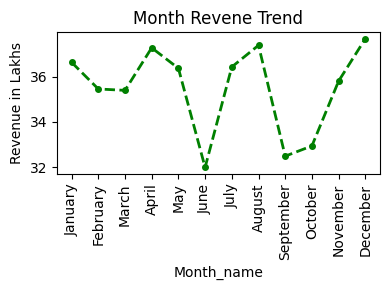

In [192]:
plt.figure(figsize= (4,3))

q1= plt.plot(
    month_revenue["month_name"],
    month_revenue["final_amount"], 
    color = "green", 
    marker = "o", 
    markersize=4, 
    linestyle = "--", 
    linewidth = 2
    )

plt.title("Month Revene Trend")
plt.xlabel("Month_name")
plt.ylabel("Revenue in Lakhs")

plt.xticks(rotation=90)         # Rotate X label into 90` for better understanding and readable 
plt.tight_layout()              # Trim extra spaces and show clean output 

plt.show()                      # For showing the chart 

<h2 style="color:Green;"><b>Monthly Profitability Insight<b></h2> 

__April, August, and December are the most profitable months. April shows strong performance due to the start of the new accounting year and increased discount-driven purchases, while August and December benefit from festive demand, including events like Diwali and Christmas/New Year, leading to higher customer spending.__

<h style="color:yellow;">“Seasonal demand and strategic discounting drive peak revenue in April, August, and December.”

<h2 style="color:Green;"><b>Low-Performing Months Analysis<b></h2> 

__July, September, and October are the least performing months, likely due to seasonal transitions that influence customer preferences and reduce overall demand.__

<h style="color:yellow;">“Seasonal shifts in customer preferences lead to lower demand and reduced performance in July, September, and October.”

### Q2. How does customer distribution look between repeat and one-time?   - Bar Chart 

In [193]:
df.head()

,transaction_id,customer_id,customer_name,age,gender,city,product_category,product_id,product_name,quantity,...,order_source,sales_channel,rating,complaint_raised,month,month_name,year,discount_range,day_name,day_type
0,TXN-05097,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,App,App,4.8,No,1,January,2023,1 - 10%,Friday,Weekday
1,TXN-13031,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,App,App,4.8,No,1,January,2023,1 - 10%,Friday,Weekday
2,TXN-19316,CUST-1001,Rahul Sharma,65,Male,Indore,Sports,PRD-404,Nivia Football,1,...,App,App,4.8,No,1,January,2023,1 - 10%,Friday,Weekday
3,TXN-09013,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,Website,Website,3.3,No,1,January,2023,1 - 10%,Monday,Weekday
4,TXN-18037,CUST-1001,Rahul Sharma,65,Male,Indore,Electronics,PRD-105,Noise Smartwatch,1,...,Website,Website,3.3,No,1,January,2023,1 - 10%,Monday,Weekday


In [194]:
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year', 'discount_range', 'day_name', 'day_type'],
      dtype='object')

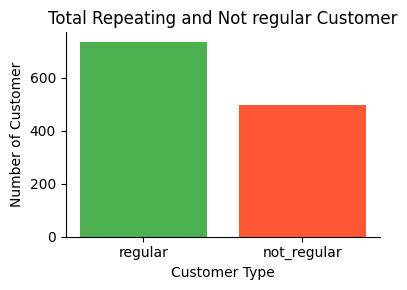

In [202]:
count_repeat = df["customer_id"].value_counts()

regular = (count_repeat > 5).sum()              # Customer they order more then 5 time     
not_regular = (count_repeat <= 5).sum()         # Custoemer they order 5 or less then 5 time 

plt.figure(figsize=(4,3))

plt.bar(
    ["regular", "not_regular"],
    [regular, not_regular], 
    color = ["#4CAF50", "#FF5733"])
plt.xlabel("Customer Type")
plt.ylabel("Number of Customer")
plt.title("Total Repeating and Not regular Customer")
plt.xticks()
plt.tight_layout()
sns.despine()


plt.show()

### Q3. How does revenue vary across discount ranges?   - Bar Chart 

C:\Users\pushp\AppData\Local\Temp\ipykernel_12176\2423800443.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_revenue = df.groupby("discount_range")["final_amount"].sum().reset_index()             # Calculate total revenue with discount


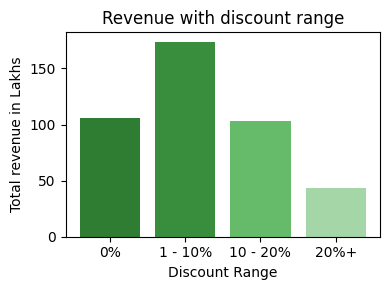

In [196]:
discount_revenue = df.groupby("discount_range")["final_amount"].sum().reset_index()             # Calculate total revenue with discount 
discount_revenue["final_amount"] = discount_revenue["final_amount"] / 100000                    # Change total revenue into Lakhs 
discount_revenue

colors = ["#2E7D32","#388E3C","#66BB6A", "#A5D6A7"]                                    # Colors for bars

plt.figure(figsize=(4,3))

q3 = plt.bar(
    discount_revenue["discount_range"],
    discount_revenue["final_amount"], 
    color = colors
)
plt.title("Revenue with discount range")
plt.xlabel("Discount Range")
plt.ylabel("Total revenue in Lakhs")
plt.tight_layout()
plt.xticks()

plt.show()

<h2 style="color:Green;"><b>Discount Performance Analysis<b></h2> 

__Moderate discounts (1–10%) deliver the strongest performance, maximizing customer engagement without sacrificing revenue.__

### Q4. Do repeat customers spend more per order than new customers?   - Bar Chart 

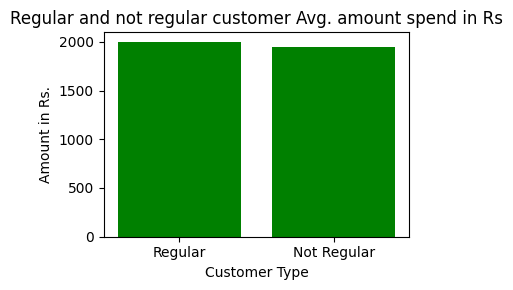

In [203]:
# Find repeat customer per order value 

repeat_customer = df["customer_id"].value_counts()                                                  # Total Customer Count 
repeat_customer = repeat_customer[repeat_customer > 5].index                                        # Filter customer order more then 5 time 
repeat_customer = df["customer_id"].isin(repeat_customer)                                           # Find all customer they order more then 5 time in main df table 
repeat_customer_order_value = round(df.loc[repeat_customer,"final_amount"].mean(),2)                # find avg order value of regular customers  
# print(repeat_customer_order_value)


# Not repeating customer

non_repeating_customer = df["customer_id"].value_counts()                                            # Total customer Count 
non_repeating_customer = non_repeating_customer[non_repeating_customer <= 5].index                   # Filter customer they order 5 or less then 5 time
non_repeating_customer = df["customer_id"].isin(non_repeating_customer)                              # find all customer they order 5 or less then 5 time in df table
non_repeating_customer_order_value = round(df.loc[non_repeating_customer, "final_amount"].mean(),2)  # Find avg order value of not regular customers 
# print(non_repeating_customer_order_value)

plt.figure(figsize= (4,3))

plt.bar(
    ["Regular", "Not Regular"], 
    [repeat_customer_order_value, non_repeating_customer_order_value], 
    color = "green"
)

plt.xlabel("Customer Type")
plt.ylabel("Amount in Rs.")
plt.title("Regular and not regular customer Avg. amount spend in Rs")
plt.xticks()
plt.tight_layout()

plt.show()


### Q5. Do customers spend more on weekends or weekdays?   - Bar Chart 

Weekday Revenue is:- 305.31Lakhs
Weekend Revenue is:- 120.46Lakhs


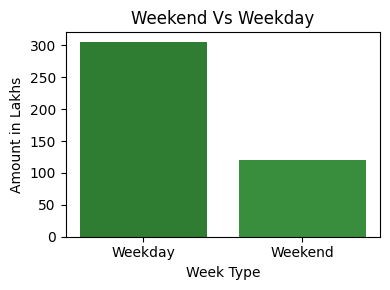

In [204]:
# Total revenue in Lakhs on weekdays 

weekday = df.loc[df["day_type"] == "Weekday"]["final_amount"].sum()       # Filter weekday with revenue 
weekday = round(weekday / 100000 ,2)                                      # Change into lakhs for easy reading 
print(f"Weekday Revenue is:- {weekday}Lakhs")                             # Final value and output 

# Total revenue in Lakhs on weekend 

weekend = df[df["day_type"] == "Weekend"]["final_amount"].sum()          # Filter weekend with revenue 
weekend = round(weekend / 100000 ,2)                                     # Change into lakhs for easy reading 
print(f"Weekend Revenue is:- {weekend}Lakhs")                            # Final value and output 

#  Showing into Bar chart 

x = ("Weekday", "Weekend")
y = (weekday, weekend)
colors = ("#2E7D32","#388E3C")

plt.figure(figsize= (4,3))

plt.bar(x,y, color = colors)
plt.title("Weekend Vs Weekday")
plt.xlabel("Week Type")
plt.ylabel("Amount in Lakhs")
plt.xticks()
plt.tight_layout()

plt.show()

### Q6 How much revenue comes from High, Medium, Low value customers? - Pie Chart and Bar Chart 

In [206]:
customer_value = df.groupby("customer_id")["final_amount"].sum().reset_index()

In [210]:
def segment(x):
    if x >= 10000:
        return "High Value"
    elif x >= 5000:
        return "Medium Value"
    else:
        return "Low Value"

customer_value["segment"] = customer_value["final_amount"].apply(segment)
df["segment"] = customer_value["segment"]

In [211]:
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year', 'discount_range', 'day_name', 'day_type', 'segment'],
      dtype='object')

        segment  final_amount
0    High Value         15.88
1     Low Value          6.44
2  Medium Value          3.90


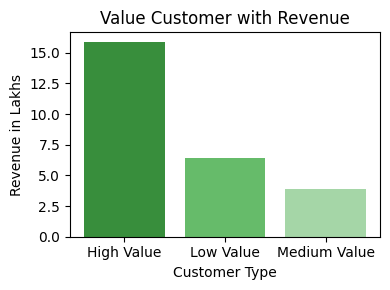

In [212]:
value_customer = df.groupby("segment")["final_amount"].sum().reset_index()
value_customer["final_amount"] = round(value_customer["final_amount"] / 100000 , 2)
print(value_customer)

colors  = ["#388E3C","#66BB6A", "#A5D6A7"]

plt.figure(figsize= (4,3))

plt.bar(value_customer["segment"], value_customer["final_amount"], color = colors)
plt.title("Value Customer with Revenue")
plt.xlabel("Customer Type")
plt.ylabel("Revenue in Lakhs")
plt.tight_layout()
plt.xticks()

plt.show()



<h2 style="color:Green;"><b>Customer Value Contribution Analysis<b></h2> 

__High-value customers generate the highest revenue (15.88), significantly outperforming low-value (6.44) and medium-value customers (3.90), indicating a strong dependency on a small group of premium customers.__

<h style="color:yellow;">“A small segment of high-value customers drives the majority of revenue, making them critical for business growth and retention.”

### Q7. How much revenue comes from different Age Group customers? - Pie Chart 

In [214]:
age_group = []

for i in df["age"]:
    if i >= 18 and i <= 30:
        age_group.append("Young Adults")
    elif i > 30 and i <= 50:
        age_group.append("Middle-Aged")
    else:
        age_group.append("Senior Adults")

df["age_group"] = age_group

       age_group  final_amount
0    Middle-Aged        182.08
1  Senior Adults        131.08
2   Young Adults        112.61


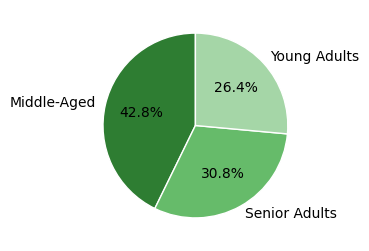

In [215]:
age_group_revenue = df.groupby("age_group")["final_amount"].sum().reset_index()
age_group_revenue["final_amount"] = round(age_group_revenue["final_amount"] / 100000 ,2)
print(age_group_revenue)


# Create a pie chart 

colors_for_pie = ["#2E7D32", "#66BB6A", "#A5D6A7"]

plt.figure(figsize= (4,3))

plt.pie(
    age_group_revenue["final_amount"],
    labels= age_group_revenue["age_group"],
    colors= colors_for_pie,
    wedgeprops= {"edgecolor":"white"},
    autopct= "%1.1f%%",
    startangle= 90
)
plt.show()

<h2 style="color:Green;"><b>Age Group Revenue Analysis<b></h2> 

__Middle-aged customers generate the highest revenue (182.08), followed by senior adults (131.08) and young adults (112.61), indicating that the middle-aged segment contributes the most to overall business revenue.__

<h style="color:yellow;">“Middle-aged customers are the primary revenue drivers, making them the most valuable segment for targeted marketing and business growth.”```

### Q8. How much revenue comes from different product category? - Line Chart

  product_category  final_amount
0           Beauty         31.77
1      Electronics        161.55
2          Fashion        155.31
3           Sports         77.15


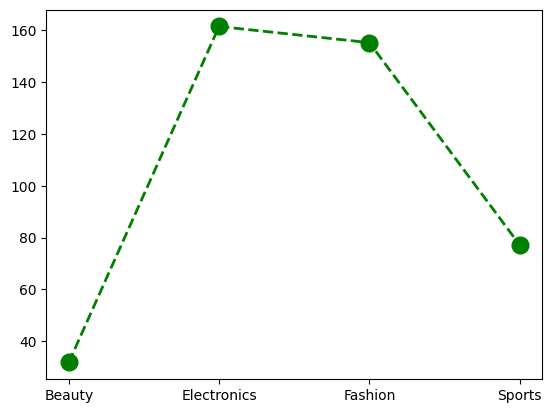

In [216]:
product_category_revenue = df.groupby("product_category")["final_amount"].sum().reset_index()
product_category_revenue["final_amount"] = round(product_category_revenue["final_amount"] / 100000 ,2)
print(product_category_revenue)

# Create a line chart 

plt.plot(
    product_category_revenue["product_category"], 
    product_category_revenue["final_amount"],
    color = "green",
    linewidth = 2, 
    linestyle = "--",
    marker = "o", 
    markersize = 12
)

<h2 style="color:Green;"><b>Product Category Revenue Analysis<b></h2> 

__Electronics (161.55) and Fashion (155.31) generate the highest revenue, significantly outperforming Sports (77.15) and Beauty (31.77), indicating strong customer demand in these categories.__

<h style="color:yellow;">“Electronics and Fashion dominate revenue contribution, making them key focus areas for maximizing business growth.”```

### Q9. Revenue based on Gender - Bar chart 

In [ ]:

weekend = df[df["day_type"] == "Weekend"]["final_amount"].sum()

Total Male revenue is:- 218.26Lakhs
Total Female Revenue is:- 207.51Lakhs


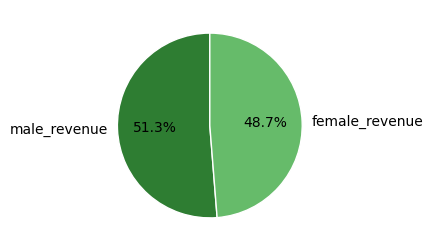

In [217]:
# Calculate Male revenue 

male_revenue = df[df["gender"] == "Male"]["final_amount"].sum()
male_revenue =round(male_revenue / 100000 ,2)
print(f"Total Male revenue is:- {male_revenue}Lakhs")

# Calculate Female revenue 

female_revenue = df[df["gender"] == "Female"]["final_amount"].sum()
female_revenue = round( female_revenue /  100000 ,2)
print(f"Total Female Revenue is:- {female_revenue}Lakhs")

# Create a Pie chart for this 

gender_revenue = [male_revenue, female_revenue]
gender_labels = ["male_revenue", "female_revenue"]
colors_for_pie = ["#2E7D32", "#66BB6A"]

plt.figure(figsize= (4,3))

plt.pie(
    gender_revenue, 
    labels= gender_labels,
    wedgeprops= {"edgecolor":"white"},
    autopct= "%1.1f%%",
    colors= colors_for_pie,
    startangle= 90
)

plt.show()

### Q10. How does product category revenue vary across gender? - Bar Chart 

gender            Female    Male
product_category                
Beauty             26.95    4.82
Electronics        54.58  106.96
Fashion           108.68   46.62
Sports             17.29   59.86


<Figure size 600x400 with 0 Axes>

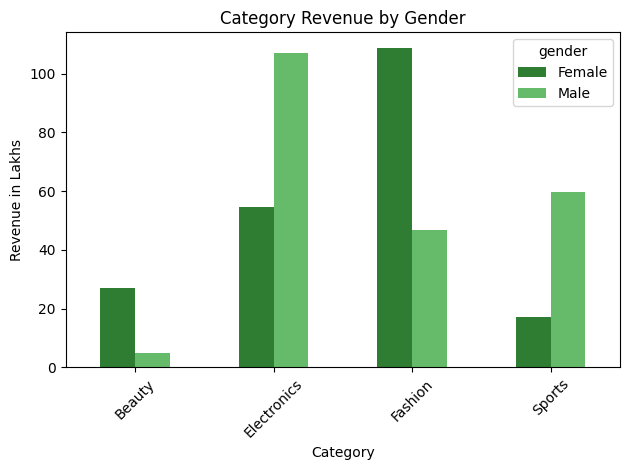

In [218]:
data = df.groupby(["product_category", "gender"])["final_amount"].sum().unstack()
data["Female"] = round(data["Female"] / 100000 ,2)
data["Male"] = round(data["Male"] / 100000 ,2)
print(data)


color_for_gender = ["#2E7D32", "#66BB6A"]
plt.figure(figsize= (6,4))

data.plot(kind="bar", color = color_for_gender)

plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Revenue in Lakhs")
plt.title("Category Revenue by Gender")

plt.tight_layout()
plt.show()

<h2 style="color:Green;"><b>Gender-wise Product Category Revenue Analysis<b></h2> 

__Revenue contribution varies significantly across genders and product categories, with males dominating in Electronics (106.96) and Sports (59.86), while females lead in Fashion (108.68) and Beauty (26.95), indicating distinct purchasing preferences.__

<h style="color:yellow;">“Customer purchasing behavior differs by gender, with clear category preferences driving revenue across segments.”```

### Q11. How does product revenue vary across gender? - Bar Chart 

<Figure size 400x300 with 0 Axes>

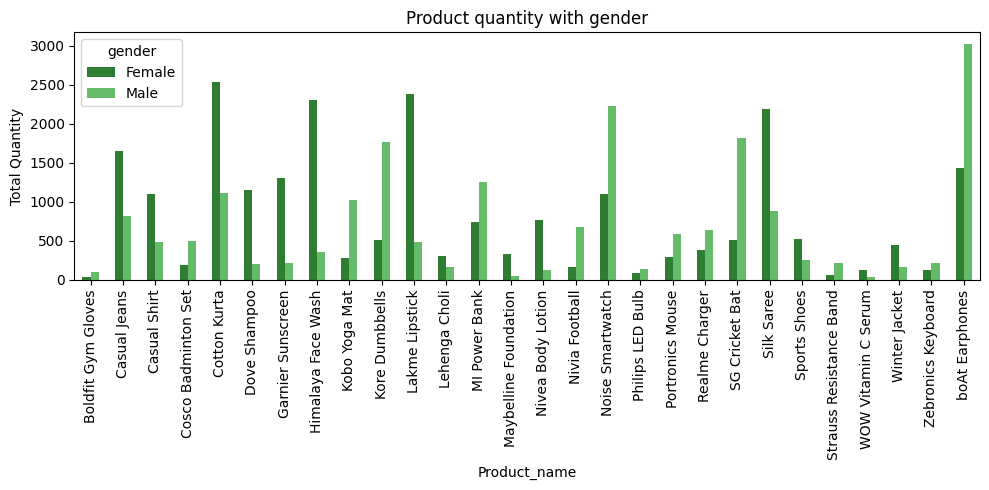

In [ ]:
product_revenue = df.groupby(["product_name","gender"])["quantity"].sum().unstack()

product_revenue.plot(kind= "bar", color = color_for_gender, figsize= (10,5))
plt.title("Product quantity with gender")
plt.xlabel("Product_name")
plt.ylabel("Total Quantity")
plt.tight_layout()
plt.xticks()

plt.show()

### Q11. Product with best Avg. Rating - Bar Chart 

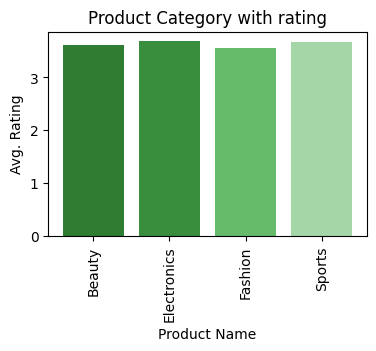

In [ ]:
product_rating = round(df.groupby("product_category")["rating"].mean().reset_index() ,2)

# Create a bar chart 
plt.figure(figsize= (4,3))

plt.bar(
    product_rating["product_category"],
    product_rating["rating"],
    color = ["#2E7D32","#388E3C","#66BB6A", "#A5D6A7"]
)
plt.title("Product Category with rating")
plt.xlabel("Product Name")
plt.ylabel("Avg. Rating")
plt.tight_layout()
plt.xticks(rotation = 90,ha="center")

plt.show()

### Q12. Which product category has the highest number of customer complaints? - Bar Chart

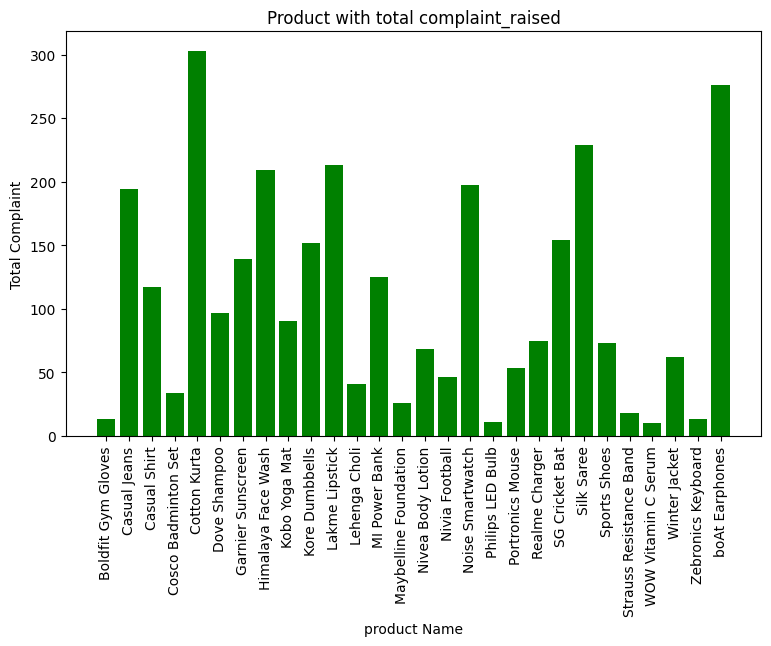

In [ ]:
product_comp = df.loc[df["complaint_raised"]== "Yes"]
product_complaint = product_comp.groupby("product_name")["complaint_raised"].count().reset_index()

# Create a bar chart 

plt.figure(figsize= (8,5))

plt.bar(
    product_complaint["product_name"],
    product_complaint["complaint_raised"],
    color = "green"
)
plt.title("Product with total complaint_raised")
plt.xlabel("product Name")
plt.ylabel("Total Complaint")
plt.tight_layout()
plt.xticks(rotation = 90)

plt.show()

<h2 style="color:Green;"><b>Product-wise Complaint Analysis<b></h2> 

__Certain products show significantly higher complaint volumes, with Cotton Kurta (303), boAt Earphones (276), Silk Saree (229), Lakme Lipstick (213), and Himalaya Face Wash (209) leading in complaints, indicating potential quality or customer satisfaction issues in these products.__

<h style="color:yellow;">“High complaint volumes in specific products highlight critical areas for quality improvement and customer experience enhancement.”```

### Q13. Which day of the week generates the highest revenue? Bar Chart 

In [ ]:
#  Creating a day no. column 

df["day_no"] = df["order_date"].dt.day_of_week

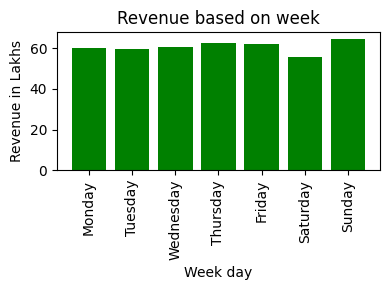

In [ ]:
week_revenue = df.groupby(["day_no","day_name"])["final_amount"].sum().reset_index()
week_revenue["final_amount"] = round(week_revenue["final_amount"] / 100000 , 2)

plt.figure( figsize= (4,3))

plt.bar(
    week_revenue["day_name"],
    week_revenue["final_amount"],
    color = "green"
)
plt.title("Revenue based on week")
plt.xlabel("Week day")
plt.ylabel("Revenue in Lakhs")
plt.xticks(rotation = 90)
plt.tight_layout()

plt.show()

### Q14. How does order status vary across different products?

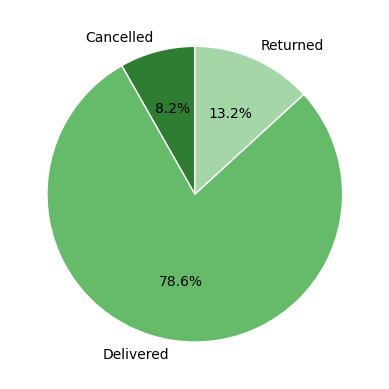

In [220]:
order_status = df.groupby("order_status")["transaction_id"].count().reset_index()
order_status

colors_for_pie = ["#2E7D32", "#66BB6A", "#A5D6A7"]
plt.Figure(figsize= (4,3))

plt.pie(
    order_status["transaction_id"], 
    labels= order_status["order_status"],
    autopct= "%1.1f%%",
    colors= colors_for_pie,
    wedgeprops= {"edgecolor":"white"},
    startangle= 90
)

plt.show()

<h2 style="color:Green;"><b>Order Status Distribution Analysis<b></h2> 

__Delivered orders (16773) dominate the total transactions, while returned (2816) and cancelled orders (1756) form a smaller but significant portion, indicating potential gaps in order fulfillment and customer satisfaction.__

<h style="color:yellow;">“High delivery rates reflect strong operations, but returns and cancellations highlight areas for improving customer experience and product quality.”```

### Q15. Which payment method is used the most by customers?

  payment_method  transaction_id
0            COD            5195
1    Credit Card            3072
2     Debit Card            3695
3            UPI            6981
4         Wallet            2402


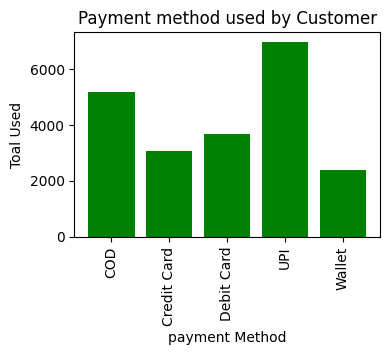

In [224]:
payment_method = df.groupby("payment_method")["transaction_id"].count().reset_index()
print(payment_method)

# Create a bar chart 

plt.figure(figsize= (4,3))

plt.bar(
    payment_method["payment_method"],
    payment_method["transaction_id"],
    color = "green"
)
plt.title("Payment method used by Customer")
plt.xlabel("payment Method")
plt.ylabel("Toal Used")
plt.tight_layout()
plt.xticks(rotation = 90)

plt.show()

<h2 style="color:Green;"><b>Payment Method Usage Analysis<b></h2> 

__UPI (6981) is the most used payment method, followed by COD (5195) and Debit Card (3695), while Credit Card (3072) and Wallet (2402) have relatively lower usage, indicating a strong preference for digital and convenient payment options.__

<h style="color:yellow;">“UPI dominates customer transactions, highlighting the growing shift towards fast and seamless digital payments.”```

### Q16. How does order status vary across different payment methods?

order_status    Cancelled  Returned
payment_method                     
COD                   422       690
Credit Card           247       388
Debit Card            284       478
UPI                   584       935
Wallet                219       325


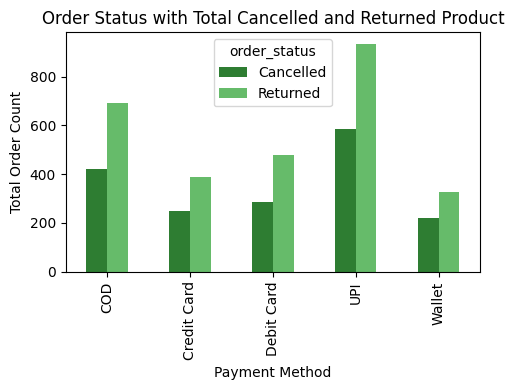

In [233]:
pay_sta = df.loc[df["order_status"] != "Delivered"]
payment_status = pay_sta.groupby(["payment_method", "order_status"])["payment_method"].count().unstack()
print(payment_status)

# Create a bar chart 

payment_status.plot(
    kind= "bar", 
    color = colors_for_pie, 
    figsize= (5,4)
)
plt.title("Order Status with Total Cancelled and Returned Product")
plt.xlabel("Payment Method")
plt.ylabel("Total Order Count")
plt.tight_layout()
plt.xticks()

plt.show()

<h2 style="color:Green;"><b>Payment Method vs Order Status Analysis<b></h2> 

__UPI shows the highest number of cancellations (584) and returns (935), followed by COD and Debit Card, indicating that widely used payment methods also experience higher order issues, while Wallet and Credit Card show relatively lower impact.__

<h style="color:yellow;">“Higher transaction volume in UPI and COD leads to increased cancellations and returns, highlighting the need to improve order reliability in these payment channels.”

### Q17. How does revenue vary across different order sources?

      order_source  final_amount
0              App        143.41
1      Facebook Ad         42.67
2  Friend Referral         10.85
3    Google Search         31.37
4     Instagram Ad         53.61
5       Mobile Web         55.60
6          Website         88.26


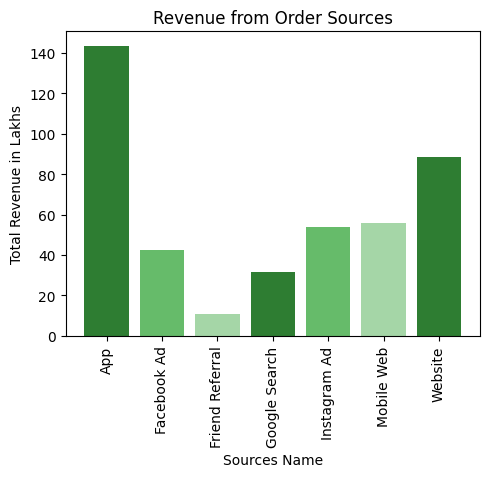

In [243]:
sources = df.groupby("order_source")["final_amount"].sum().reset_index()
sources["final_amount"] = round(sources["final_amount"] / 100000 ,2)
print(sources)

# Create a bar chart 

plt.figure(figsize= (5,4))

plt.bar(
    sources["order_source"],
    sources["final_amount"],
    color =  colors_for_pie,
)
plt.title("Revenue from Order Sources")
plt.xlabel("Sources Name")
plt.ylabel("Total Revenue in Lakhs")
plt.tight_layout()
plt.xticks(rotation = 90)

plt.show()


<h2 style="color:Green;"><b>Order Source Revenue Analysis<b></h2> 

__The App (143.41) generates the highest revenue, followed by Website (88.26) and Mobile Web (55.60), while paid channels like Instagram Ads (53.61) and Facebook Ads (42.67) contribute moderately, and Friend Referral (10.85) shows the lowest impact.__

<h style="color:yellow;">“Owned platforms like App and Website dominate revenue, highlighting stronger customer trust and engagement compared to external channels.”```

### Q18. Which order source generates the highest number of transactions?

In [251]:
df.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'age', 'gender',
       'city', 'product_category', 'product_id', 'product_name', 'quantity',
       'unit_price', 'total_price', 'discount_percent', 'final_amount',
       'delivery_charge', 'payment_method', 'order_date', 'delivery_days',
       'order_status', 'return_delivery_charge', 'order_source',
       'sales_channel', 'rating', 'complaint_raised', 'month', 'month_name',
       'year', 'discount_range', 'day_name', 'day_type', 'segment',
       'age_group'],
      dtype='object')

      order_source  transaction_id
0              App            7239
1      Facebook Ad            2138
2  Friend Referral             587
3    Google Search            1632
4     Instagram Ad            2692
5       Mobile Web            2841
6          Website            4216


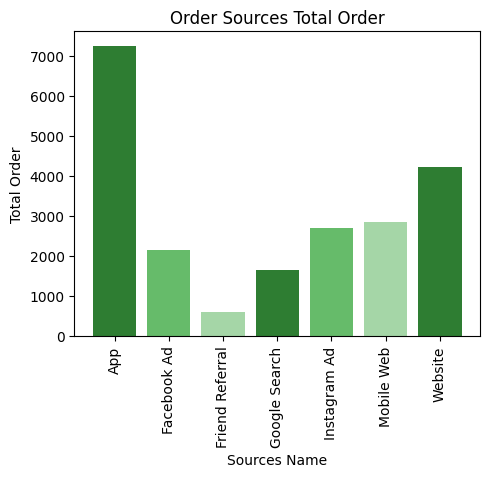

In [253]:
sources_count = df.groupby("order_source")["transaction_id"].count().reset_index()
print(sources_count)

# Create a bar chart 

plt.figure(figsize= (5,4))

plt.bar(
    sources_count["order_source"],
    sources_count["transaction_id"],
    color =  colors_for_pie,
)
plt.title("Order Sources Total Order")
plt.xlabel("Sources Name")
plt.ylabel("Total Order")
plt.tight_layout()
plt.xticks(rotation = 90)

plt.show()

<h2 style="color:Green;"><b>Order Source Transaction Analysis<b></h2> 

__The App (7239) drives the highest number of transactions, followed by Website (4216) and Mobile Web (2841), while Instagram Ads (2692) and Facebook Ads (2138) contribute moderately, and Friend Referral (587) has the lowest transaction volume.__

<h style="color:yellow;">“The App dominates customer transactions, highlighting its role as the primary channel for user engagement and conversions.”```